importing required libraries 

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

importing data(CSV file) as dataframe(pandas)

In [2]:
df=pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


shape of dataframe:-

In [5]:
df.shape

(1000, 8)

### DATA information :
data have 1000 rows and 8 coulmns , which are:-
1. gender
2. race_ethnicity	
3. parental_level_of_education	
4. lunch	
5. test_preparation_course	
6. math_score	
7. reading_score	
8. writing_score

### Actions to perform on Data 
- check for missing values 
- check duplicates 
- check datadypes
- check number of unique values for each feature 
- check statistics of dataset
- check and differentiate different catagories present in features

##### checking missing values

In [9]:
df.isnull().mean() * 100

gender                         0.0
race_ethnicity                 0.0
parental_level_of_education    0.0
lunch                          0.0
test_preparation_course        0.0
math_score                     0.0
reading_score                  0.0
writing_score                  0.0
dtype: float64

as we can see here 0% values are missing . which is good . 
if missing % was higher than 60% we could have drop that coulmn.
Check percentage of missing values.if numerical data is missing that we could have fill it we mean/median (depending on skewness or distribution). for catagorical we could have use mode to fill NaN value . for complex dataset  we could have use KNN or iterative imputer. 

##### check duplicates


In [11]:
df.duplicated().sum()

0

 no duplicate present

##### check data type

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


##### check unique values

In [14]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

##### statistics of dataset

In [15]:
df.describe()


,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


##### insights:-
- from above observation data(numerical), mean is very close to eachother .
- all std deviations are close 
- minimum for maths is 0, while for writing for reading is 17 (students scored slighly better in reading and writing than maths )
-Writing and reading scores are very similar suggesting strong correlation.
- majority performs in the avg range 

##### Exploring data 


In [21]:
print("catagories in feature 'gender':- ", end="")
print(df['gender'].unique())
print("catagories in feature 'race_ethnicity':- ", end="")
print(df['race_ethnicity'].unique())
print("catagories in feature 'parental_level_of_education':- ", end="")
print(df['parental_level_of_education'].unique())
print("catagories in feature 'lunch':- ", end="")
print(df['lunch'].unique())
print("catagories in feature 'test_preparation_course':- ", end="")
print(df['test_preparation_course'].unique())


catagories in feature 'gender':- ['female' 'male']
catagories in feature 'race_ethnicity':- ['group B' 'group C' 'group A' 'group D' 'group E']
catagories in feature 'parental_level_of_education':- ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
catagories in feature 'lunch':- ['standard' 'free/reduced']
catagories in feature 'test_preparation_course':- ['none' 'completed']


##### defining numerical and catgorical columns

In [25]:
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'O']
catagorical_feature=[feature for feature in df.columns if df[feature].dtype == 'O']

print('we have {} number of numerical feature : {}'.format(len(numerical_features),numerical_features))
print('we have {} number of catagorical features: {}'.format(len(catagorical_feature),catagorical_feature))

we have 3 number of numerical feature : ['math_score', 'reading_score', 'writing_score']
we have 5 number of catagorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


##### Adding columns for total score and Average score 

In [26]:
df['Total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['Average_score']=df['Total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


lets check how many students got full marks


In [32]:
maths_full_marks=(df['math_score']==100).sum()
reading_full_marks=(df['reading_score']==100).sum()
writing_full_marks=(df['writing_score']==100).sum()
print("Number of students who got full marks in Maths:-",maths_full_marks)
print("Number of students who got full marks in Reading:-",reading_full_marks)
print("Number of students who got full marks in Writing:-",writing_full_marks)

Number of students who got full marks in Maths:- 7
Number of students who got full marks in Reading:- 17
Number of students who got full marks in Writing:- 14


In [ ]:
## found a better/efficent way 
for col in ['math_score','reading_score','writing_score']:
    print(f"Number of students who got full marks in {col}:", (df[col]==100).sum())

Number of students who got full marks in math_score: 7
Number of students who got full marks in reading_score: 17
Number of students who got full marks in writing_score: 14


 lets check how many got low marks (less than 20 )

In [34]:
for col in ['math_score','reading_score','writing_score']:
    print(f"Number of students who got marks <20 in {col}:", (df[col]<=20).sum())

Number of students who got marks <20 in math_score: 4
Number of students who got marks <20 in reading_score: 1
Number of students who got marks <20 in writing_score: 3


insights:-
- performance of students is worse in maths 
- best perfomance is in reading

#### Exploring Data through Visualization
##### visualizing average score distribution to make some conclusion
- Histogram and KDE

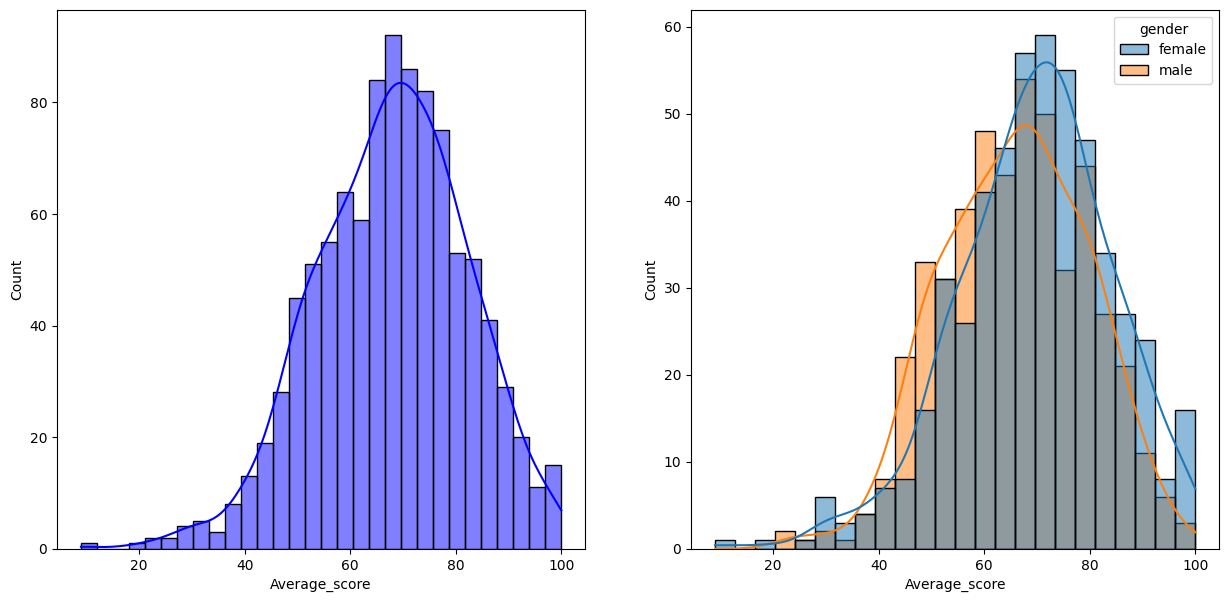

In [36]:
## histogram and kde
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average_score',bins=30,kde=True,color='b')
plt.subplot(122)
sns.histplot(data=df,x='Average_score',kde=True,hue='gender')
plt.show()

we can clearly see that female students tend to perform better than male students 

#### relation of lunch with average score

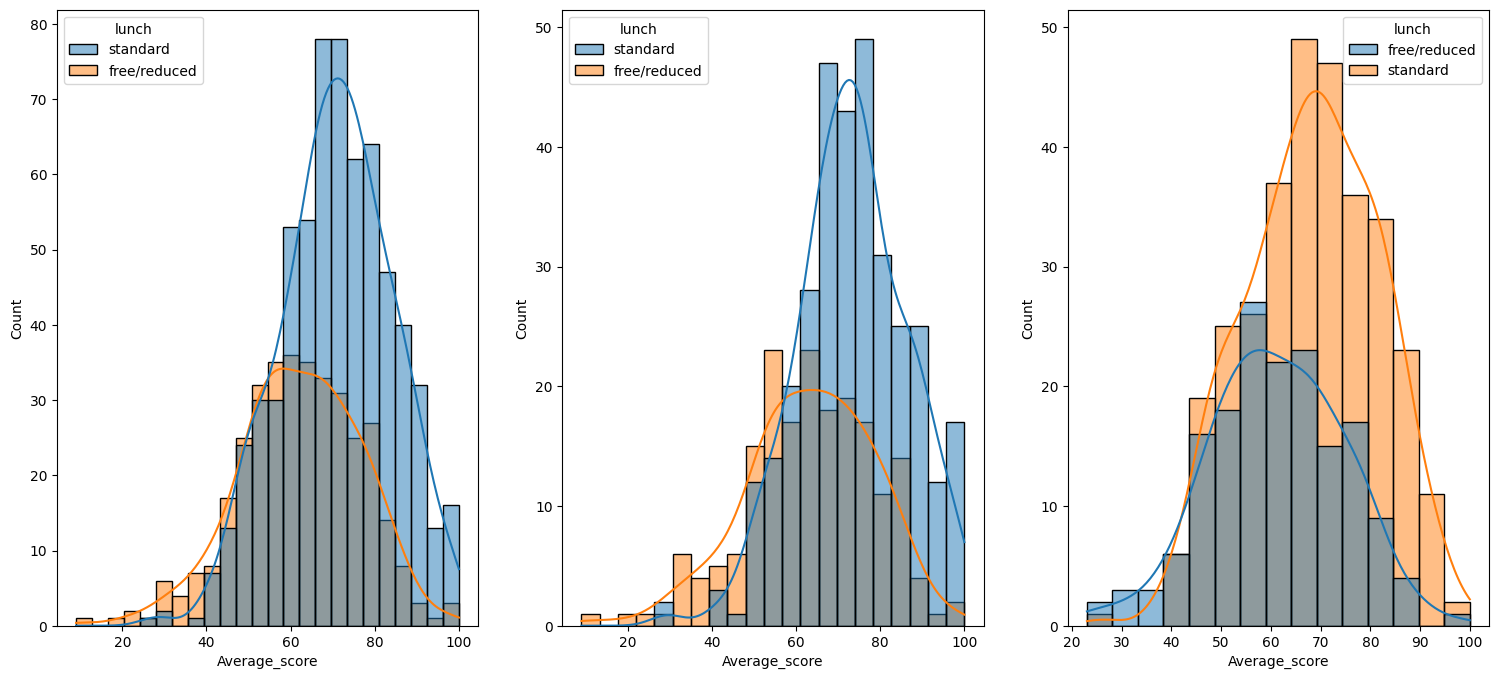

In [39]:
fig,axs=plt.subplots(1,3,figsize=(25,8))
plt.subplot(141)
sns.histplot(data=df,x='Average_score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average_score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average_score',kde=True,hue='lunch')
plt.show()

#### insights:-
- students(male and female) who had standerd type of lunch tends to perform better than students who had free/reduced type lunch

In [40]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


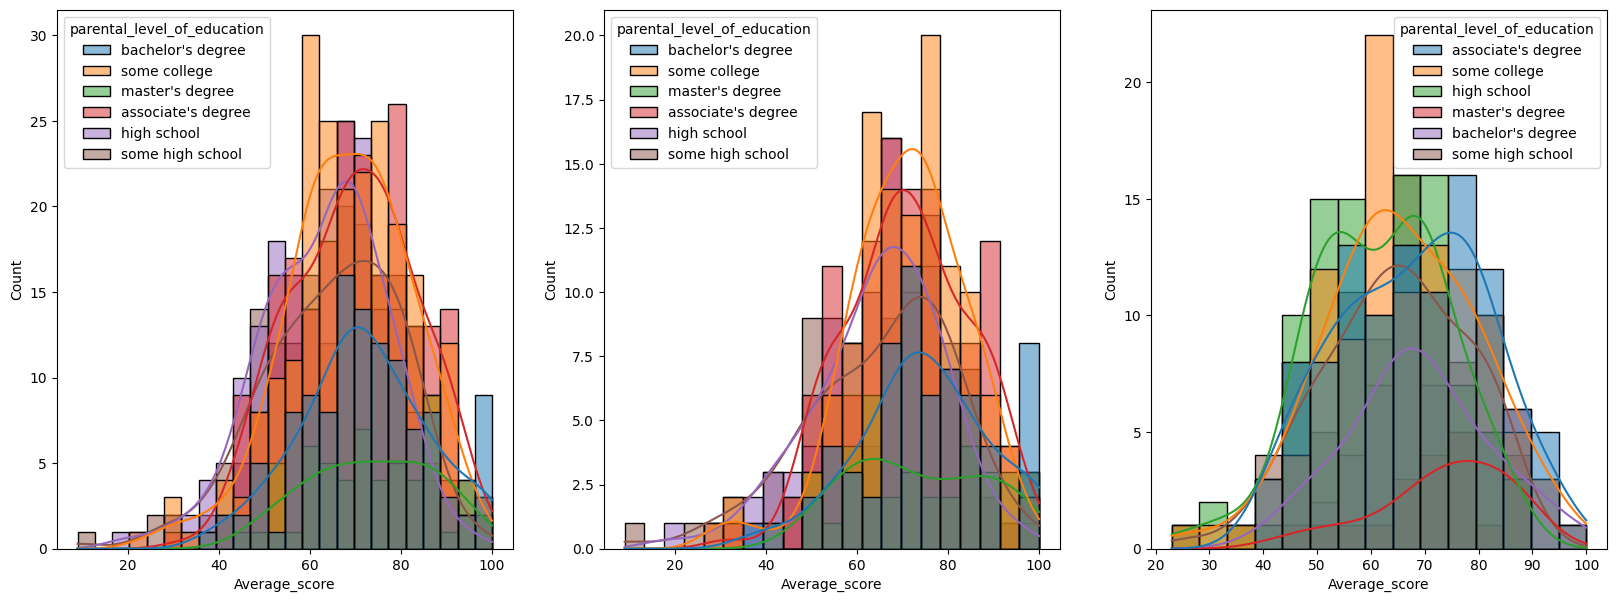

In [44]:
plt.subplots(1,3,figsize=(20,7))
plt.subplot(131)
sns.histplot(data=df,x='Average_score',kde=True,hue='parental_level_of_education')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='Average_score',kde=True,hue='parental_level_of_education')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='Average_score',kde=True,hue='parental_level_of_education')
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.

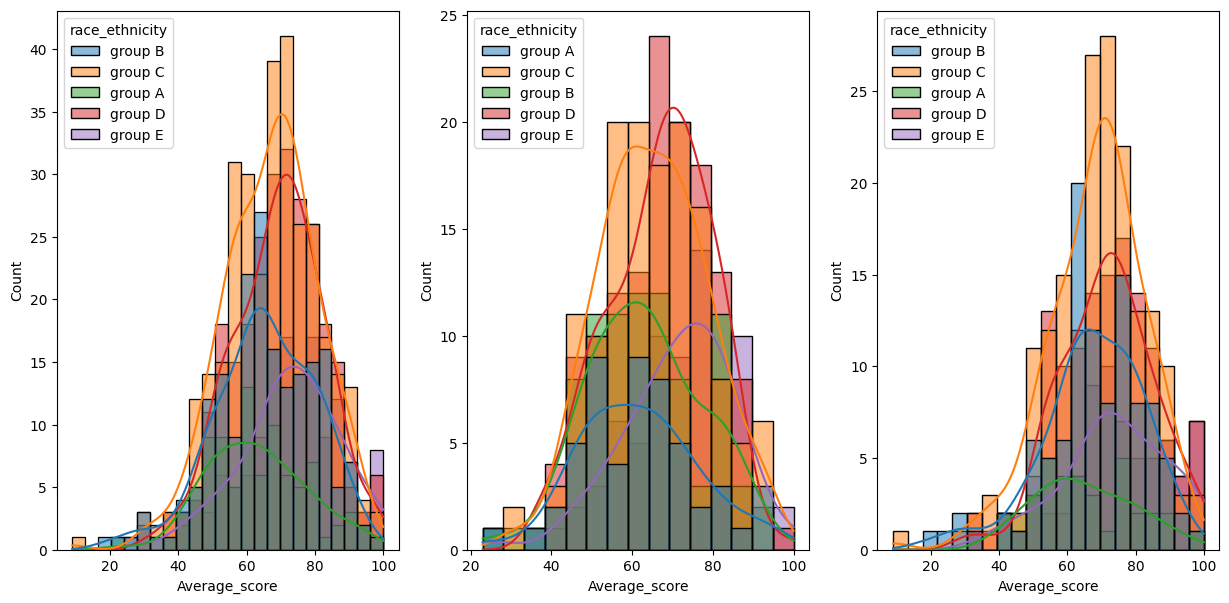

In [46]:
plt.subplots(1,3,figsize=(15,7))
plt.subplot(131)
sns.histplot(data=df,x='Average_score',kde=True,hue='race_ethnicity')

plt.subplot(132)
sns.histplot(data=df[df['gender']=='male'],x='Average_score',kde=True,hue='race_ethnicity')
plt.subplot(133)
sns.histplot(data=df[df['gender']=='female'],x='Average_score',kde=True,hue='race_ethnicity')
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

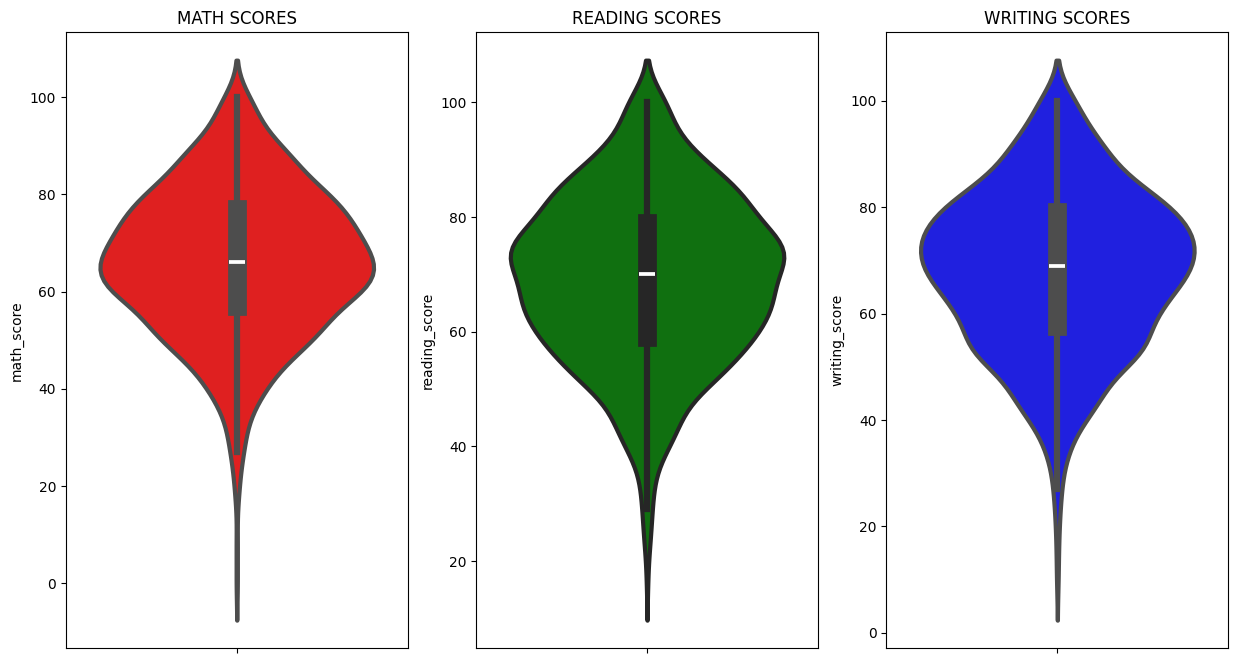

In [49]:
plt.figure(figsize=(15,8))
plt.subplot(131)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(132)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(133)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### Multivariate analysis using pieplot

In [52]:
df['gender'].count()

1000

In [53]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


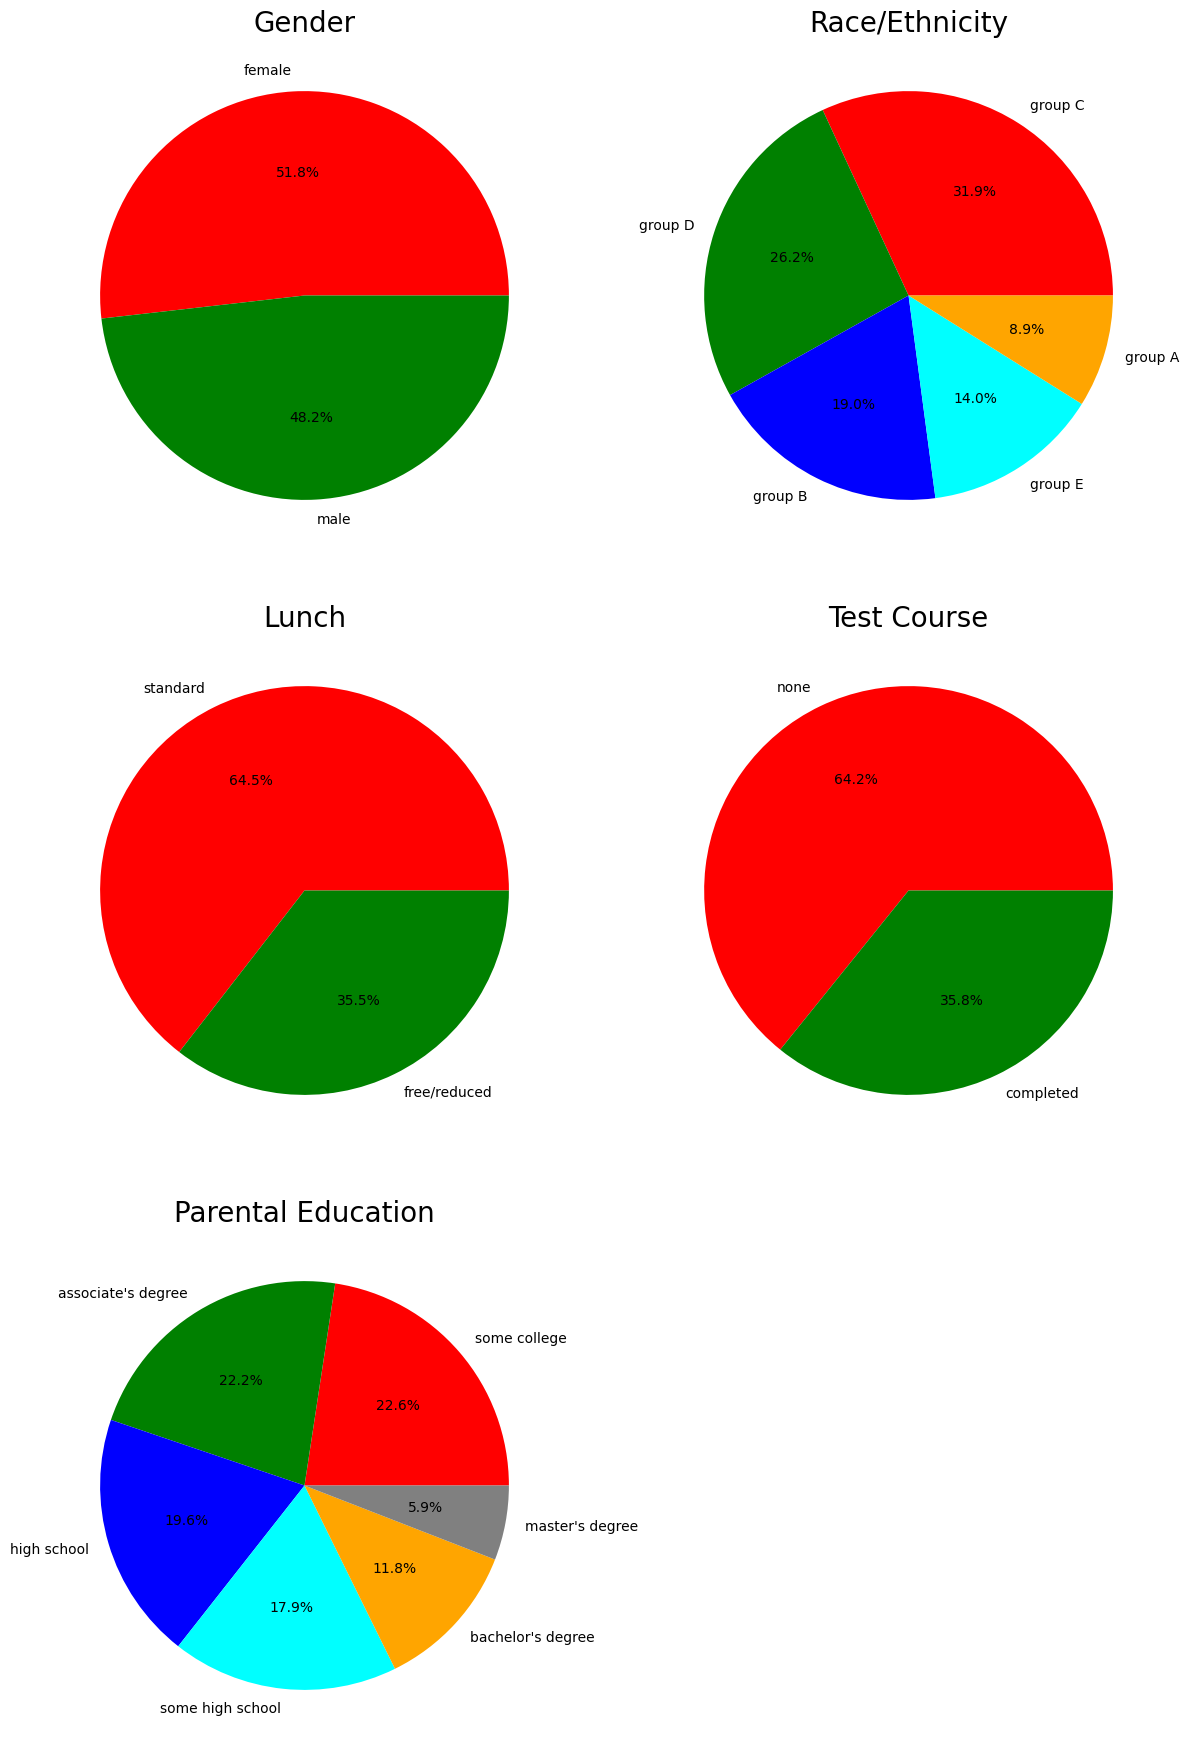

In [62]:
plt.subplots(2,3,figsize=(12,18))

columns = [
    'gender',
    'race_ethnicity',
    'lunch',
    'test_preparation_course',
    'parental_level_of_education'
]

titles = [
    'Gender',
    'Race/Ethnicity',
    'Lunch',
    'Test Course',
    'Parental Education'
]

colors = [
    ['red','green'],
    ['red','green','blue','cyan','orange'],
    ['red','green'],
    ['red','green'],
    ['red','green','blue','cyan','orange','grey']
]

for i, col in enumerate(columns): 
    
    plt.subplot(3,2,i+1)
    
    size = df[col].value_counts()
    labels = size.index
    
    plt.pie(size, labels=labels, colors=colors[i], autopct='%1.1f%%')
    
    plt.title(titles[i], fontsize=20)
    plt.axis('off')

plt.tight_layout()
plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### # Feature Wise Visualization
#### GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

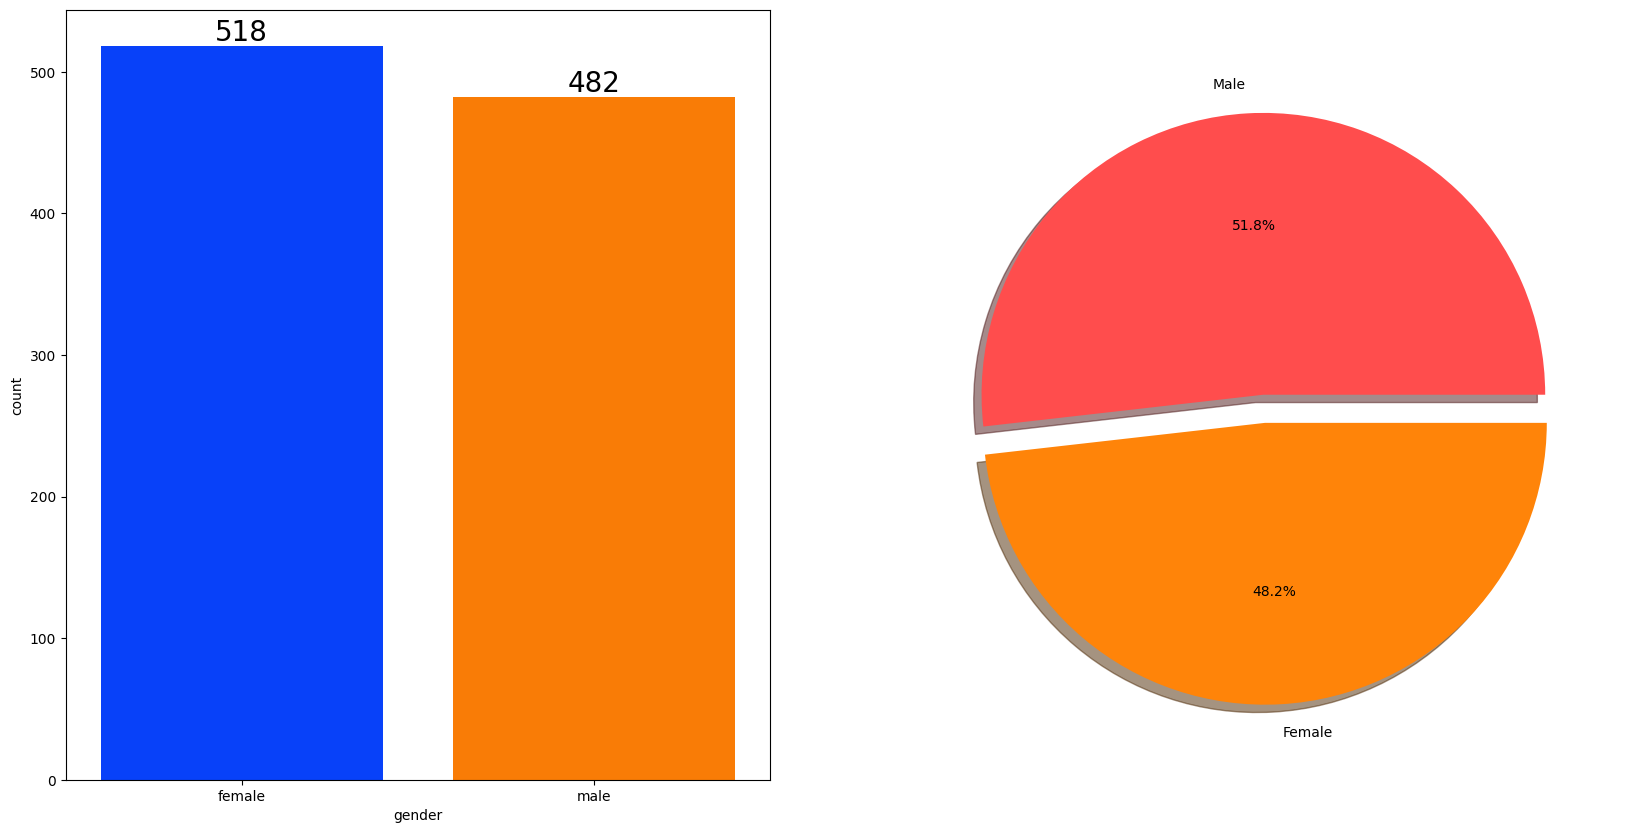

In [67]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d',"#ff8409"])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

In [69]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [75]:
gender_group=df.groupby('gender')[['math_score','reading_score','writing_score','Total_score',	'Average_score']].mean()
gender_group

,math_score,reading_score,writing_score,Total_score,Average_score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


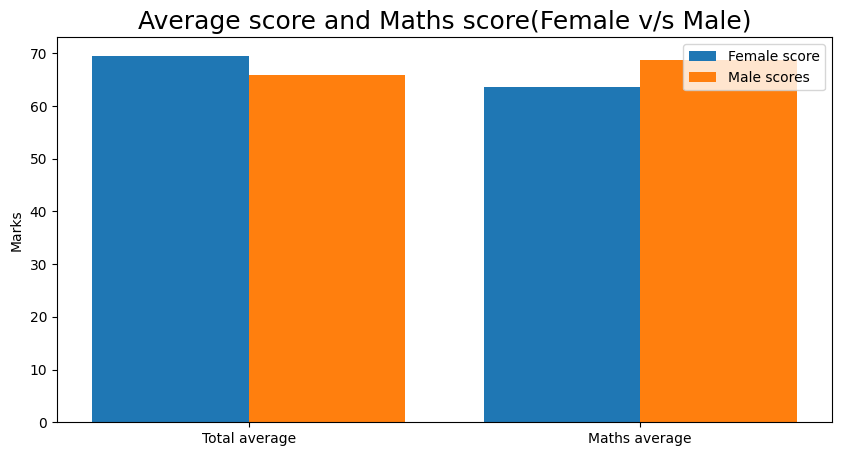

In [101]:
plt.figure(figsize=(10,5))

X = ['Total average', 'Maths average']

female_scores=[gender_group['Average_score'][0],gender_group['math_score'][0]]
male_scores=[gender_group['Average_score'][1],gender_group['math_score'][1]]

X_axis=np.arange(len(X))
plt.bar(X_axis-.20,female_scores,0.4,label='Female score')
plt.bar(X_axis+.20,male_scores,0.4, label='Male scores')
plt.ylabel("Marks")
plt.xticks(X_axis,X)
plt.title("Average score and Maths score(Female v/s Male)",fontsize=18)
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.